In [311]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [312]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os


In [453]:
model_name = 'DT'

In [454]:
path = './Final_Results/HD/'+model_name+"/"

In [455]:
dfs = {100:{}, 90:{}, 80:{}, 70:{}, 60:{}, 50:{}}

isExist = os.path.exists(path)

if isExist:
    for file_name in os.listdir(path):
        if file_name.endswith(".csv"):
            with open(path+file_name, 'r') as file:
                df = pd.read_csv(file)
                num_models = int(file_name.split('_')[0])
                agreement_rate = float(file_name.split('_')[-3])
                dfs[num_models][agreement_rate] = df
            
    derived_label_match_results = {100:{}, 90:{}, 80:{}, 70:{}, 60:{}, 50:{}}
    
    for num_models in dfs:
        for agreement_rate in dfs[num_models]:
            df = dfs[num_models][agreement_rate]
            derived_label_match = df.loc[df['description']=='label match with the origial labels for Hungary']['value'].item()
    #         derived_label_match = derived_label_match.split('\n')[1]
    #         derived_label_match = [x.split(' ')[0] for x in derived_label_match]
            derived_label_match_results[num_models][agreement_rate] = derived_label_match

    for num_models in derived_label_match_results:
        derived_label_match_results[num_models] = dict(sorted(derived_label_match_results[num_models].items()))

In [456]:
# derived_label_match_results.keys()
# derived_label_match_results.values()
derived_label_match_results[100]

{0.5: 0.7925170068027211,
 0.6: 0.7891156462585034,
 0.7: 0.8378378378378378,
 0.8: 0.8378378378378378,
 0.9: 0.8854625550660793,
 1.0: 0.8975609756097561}

In [457]:
pd.set_option('display.max_colwidth', None)

In [458]:
display(dfs[50][0.8])

,s_no,description,value
0,1.1,Train-test on Cleveland,0.742732
1,1.1a,Train-test on Hungary,0.788954
2,1.1b,Train on original Cleveland test on original Hungary,0.789116
3,1.2,Train-test on derived Hungary 259,0.934163
4,1.2a,label match with the origial labels for Hungary,0.837838
5,1.3,Train on original Cleveland test on derived Hungary,1.000000
6,1.4,Train on derived Hungary test on Cleveland,0.712871
7,1.5,Train and test on combined Cleveland Hungary,0.879077
8,1.6,Train on combined Cleveland(50%) Hungary and test on 50% Cleveland,0.756579
9,1.7,Train on combined Cleveland Hungary(50%) and test on 50% Hungary,1.000000


In [459]:
base_dataset_count = 303
derived_dataset_count = 294

base_dataset = "Cleveland"
derived_dataset = "Hungary"

fwd_exp_results = {100:{}, 90:{}, 80:{}, 70:{}, 60:{}, 50:{}}
bkd_exp_results = {100:{}, 90:{}, 80:{}, 70:{}, 60:{}, 50:{}}

for num_models in dfs:
    for agreement_rate in dfs[num_models]:
        df = dfs[num_models][agreement_rate]
        num_labelled_fwd_exp = int(df.loc[df['s_no']=='1.2']['description'].item().split()[-1])
        num_labelled_bkd_exp = int(df.loc[df['s_no']=='1.8']['description'].item().split()[-1])
        # fwd_exp_results[num_models][agreement_rate] = (num_labelled_fwd_exp / hg_total)*100
        # bkd_exp_results[num_models][agreement_rate] = (num_labelled_bkd_exp / cl_total)*100
        fwd_exp_results[num_models][agreement_rate] = (num_labelled_fwd_exp)
        bkd_exp_results[num_models][agreement_rate] = (num_labelled_bkd_exp)

for num_models in derived_label_match_results:
    derived_label_match_results[num_models] = dict(sorted(derived_label_match_results[num_models].items()))
    fwd_exp_results[num_models] = dict(sorted(fwd_exp_results[num_models].items()))
    bkd_exp_results[num_models] = dict(sorted(bkd_exp_results[num_models].items()))

In [460]:
get_model_key = [100, 90, 80, 70, 60, 50]
count_correctly_labelled = {100:{}, 90:{}, 80:{}, 70:{}, 60:{}, 50:{}}

for key in get_model_key:

    perc_match = derived_label_match_results[key]
    count_match = fwd_exp_results[key]
    
    for perc_key in perc_match.keys():
        count_correctly_labelled[key][perc_key] = int(np.round(perc_match[perc_key] * count_match[perc_key]))
    

# print({key: [int(np.round(perc*count)) for (perc, count) in zip(perc_match.values(), count_match.values())]})
# print(count_correctly_labelled)

In [461]:
model_name, count_correctly_labelled

('DT',
 {100: {0.5: 233, 0.6: 232, 0.7: 217, 0.8: 217, 0.9: 201, 1.0: 184},
  90: {0.5: 233, 0.6: 232, 0.7: 217, 0.8: 217, 0.9: 198, 1.0: 184},
  80: {0.5: 234, 0.6: 232, 0.7: 217, 0.8: 217, 0.9: 200, 1.0: 184},
  70: {0.5: 235, 0.6: 232, 0.7: 217, 0.8: 217, 0.9: 198, 1.0: 184},
  60: {0.5: 232, 0.6: 232, 0.7: 217, 0.8: 217, 0.9: 209, 1.0: 184},
  50: {0.5: 232, 0.6: 232, 0.7: 217, 0.8: 217, 0.9: 198, 1.0: 184}})

In [462]:
# [int(np.round(perc*count)) for (perc, count) in zip(perc_match.values(), count_match.values())]

Why the below code is not working?

In [463]:
# {key: [ele1 * ele2 for (ele1, ele2) in zip(perc_match[key], val2)] for (key, val2) in zip(perc_match.keys(), count_match.values())}

In [464]:
model_name, count_correctly_labelled

('DT',
 {100: {0.5: 233, 0.6: 232, 0.7: 217, 0.8: 217, 0.9: 201, 1.0: 184},
  90: {0.5: 233, 0.6: 232, 0.7: 217, 0.8: 217, 0.9: 198, 1.0: 184},
  80: {0.5: 234, 0.6: 232, 0.7: 217, 0.8: 217, 0.9: 200, 1.0: 184},
  70: {0.5: 235, 0.6: 232, 0.7: 217, 0.8: 217, 0.9: 198, 1.0: 184},
  60: {0.5: 232, 0.6: 232, 0.7: 217, 0.8: 217, 0.9: 209, 1.0: 184},
  50: {0.5: 232, 0.6: 232, 0.7: 217, 0.8: 217, 0.9: 198, 1.0: 184}})

('SVM',
 {100: [244, 244, 248, 249, 249, 244],
  90: [244, 244, 248, 250, 249, 237],
  80: [244, 245, 249, 250, 250, 238],
  70: [244, 245, 247, 250, 248, 244],
  60: [244, 247, 247, 250, 248, 243],
  50: [245, 247, 249, 250, 249, 245]})

('LR',
 {100: [239, 237, 239, 237, 232, 217],
  90: [239, 239, 241, 237, 231, 219],
  80: [238, 239, 240, 236, 232, 222],
  70: [238, 237, 240, 240, 232, 223],
  60: [241, 238, 240, 239, 233, 226],
  50: [241, 240, 241, 243, 230, 225]})

('DT',
 {100: [233, 232, 217, 217, 201, 184],
  90: [233, 232, 217, 217, 198, 184],
  80: [234, 232, 217, 217, 200, 184],
  70: [235, 232, 217, 217, 198, 184],
  60: [232, 232, 217, 217, 209, 184],
  50: [232, 232, 217, 217, 198, 184]})  

  ('RF',
 {100: [240, 245, 239, 237, 231, 181],
  90: [240, 245, 241, 236, 233, 190],
  80: [242, 245, 240, 237, 233, 181],
  70: [241, 244, 240, 238, 232, 180],
  60: [240, 245, 240, 237, 233, 189],
  50: [239, 244, 240, 239, 232, 202]})

  ('XGB',
 {100: [229, 230, 225, 222, 225, 199],
  90: [230, 229, 227, 223, 226, 196],
  80: [231, 231, 224, 223, 227, 195],
  70: [231, 231, 222, 224, 220, 196],
  60: [231, 231, 226, 222, 228, 199],
  50: [230, 231, 224, 222, 229, 207]})

In [465]:
derived_label_match_results

{100: {0.5: 0.7925170068027211,
  0.6: 0.7891156462585034,
  0.7: 0.8378378378378378,
  0.8: 0.8378378378378378,
  0.9: 0.8854625550660793,
  1.0: 0.8975609756097561},
 90: {0.5: 0.7925170068027211,
  0.6: 0.7891156462585034,
  0.7: 0.8378378378378378,
  0.8: 0.8378378378378378,
  0.9: 0.8878923766816144,
  1.0: 0.8975609756097561},
 80: {0.5: 0.7959183673469388,
  0.6: 0.7891156462585034,
  0.7: 0.8378378378378378,
  0.8: 0.8378378378378378,
  0.9: 0.8888888888888888,
  1.0: 0.8975609756097561},
 70: {0.5: 0.7993197278911565,
  0.6: 0.7891156462585034,
  0.7: 0.8378378378378378,
  0.8: 0.8378378378378378,
  0.9: 0.8839285714285714,
  1.0: 0.8975609756097561},
 60: {0.5: 0.7891156462585034,
  0.6: 0.7891156462585034,
  0.7: 0.8378378378378378,
  0.8: 0.8378378378378378,
  0.9: 0.8636363636363636,
  1.0: 0.8975609756097561},
 50: {0.5: 0.7891156462585034,
  0.6: 0.7891156462585034,
  0.7: 0.8378378378378378,
  0.8: 0.8378378378378378,
  0.9: 0.8839285714285714,
  1.0: 0.8975609756097561

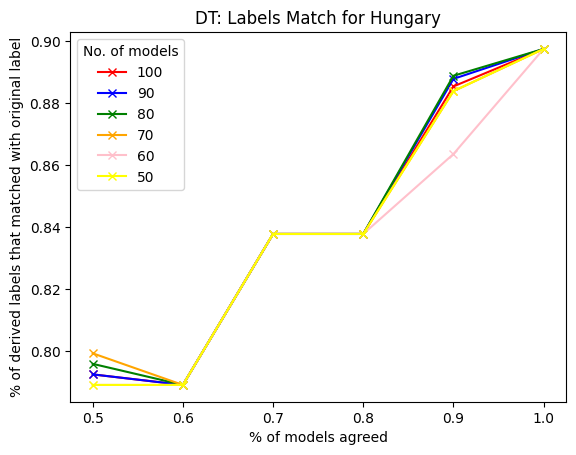

In [466]:
fig = plt.figure()
# x = 
plt.plot(derived_label_match_results[100].keys(), derived_label_match_results[100].values(), marker='x', color='red', label='100')
# plt.scatter(bkd_exp_results[100].keys(), derived_label_match_results[100].values(), s=list(bkd_exp_results[100].values()), color='red', alpha=0.6)

plt.plot(derived_label_match_results[90].keys(), derived_label_match_results[90].values(), marker='x', color='blue', label='90')
# plt.scatter(bkd_exp_results[90].keys(), derived_label_match_results[90].values(), s=list(bkd_exp_results[90].values()), color='blue', alpha=0.6)

plt.plot(derived_label_match_results[80].keys(), derived_label_match_results[80].values(), marker='x', color='green', label='80')
# plt.scatter(bkd_exp_results[80].keys(), derived_label_match_results[80].values(), s=list(bkd_exp_results[80].values()), color='green', alpha=0.6)

plt.plot(derived_label_match_results[70].keys(), derived_label_match_results[70].values(), marker='x', color='orange', label='70')
# plt.scatter(bkd_exp_results[70].keys(), derived_label_match_results[70].values(), s=list(bkd_exp_results[70].values()), color='orange', alpha=0.6)

plt.plot(derived_label_match_results[60].keys(), derived_label_match_results[60].values(), marker='x', color='pink', label='60')
# plt.scatter(bkd_exp_results[60].keys(), derived_label_match_results[60].values(), s=list(bkd_exp_results[60].values()), color='pink', alpha=0.6)

plt.plot(derived_label_match_results[50].keys(), derived_label_match_results[50].values(), marker='x', color='yellow', label='50')
# plt.scatter(bkd_exp_results[50].keys(), derived_label_match_results[50].values(), s=list(bkd_exp_results[50].values()), color='yellow', alpha=0.6)

plt.xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.xlabel("% of models agreed")
plt.ylabel("% of derived labels that matched with original label")
plt.legend(title='No. of models')
plt.title("{}".format(model_name+": Labels Match for "+derived_dataset))

plt.savefig(model_name+'_Labels_Match_Forward_Expr.png', dpi=600)

In [467]:
fwd_exp_results

{100: {0.5: 294, 0.6: 294, 0.7: 259, 0.8: 259, 0.9: 227, 1.0: 205},
 90: {0.5: 294, 0.6: 294, 0.7: 259, 0.8: 259, 0.9: 223, 1.0: 205},
 80: {0.5: 294, 0.6: 294, 0.7: 259, 0.8: 259, 0.9: 225, 1.0: 205},
 70: {0.5: 294, 0.6: 294, 0.7: 259, 0.8: 259, 0.9: 224, 1.0: 205},
 60: {0.5: 294, 0.6: 294, 0.7: 259, 0.8: 259, 0.9: 242, 1.0: 205},
 50: {0.5: 294, 0.6: 294, 0.7: 259, 0.8: 259, 0.9: 224, 1.0: 205}}

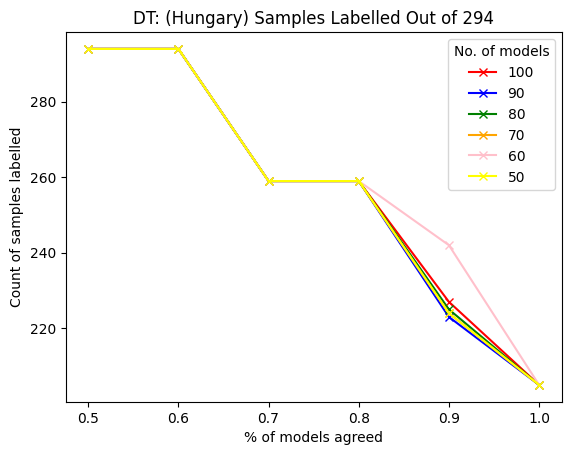

In [468]:
fig = plt.figure()
# x = 
plt.plot(fwd_exp_results[100].keys(), fwd_exp_results[100].values(), marker='x', color='red', label='100')
# plt.scatter(bkd_exp_results[100].keys(), derived_label_match_results[100].values(), s=list(bkd_exp_results[100].values()), color='red', alpha=0.6)

plt.plot(fwd_exp_results[90].keys(), fwd_exp_results[90].values(), marker='x', color='blue', label='90')
# plt.scatter(bkd_exp_results[90].keys(), derived_label_match_results[90].values(), s=list(bkd_exp_results[90].values()), color='blue', alpha=0.6)

plt.plot(fwd_exp_results[80].keys(), fwd_exp_results[80].values(), marker='x', color='green', label='80')
# plt.scatter(bkd_exp_results[80].keys(), derived_label_match_results[80].values(), s=list(bkd_exp_results[80].values()), color='green', alpha=0.6)

plt.plot(fwd_exp_results[70].keys(), fwd_exp_results[70].values(), marker='x', color='orange', label='70')
# plt.scatter(bkd_exp_results[70].keys(), derived_label_match_results[70].values(), s=list(bkd_exp_results[70].values()), color='orange', alpha=0.6)

plt.plot(fwd_exp_results[60].keys(), fwd_exp_results[60].values(), marker='x', color='pink', label='60')
# plt.scatter(bkd_exp_results[60].keys(), derived_label_match_results[60].values(), s=list(bkd_exp_results[60].values()), color='pink', alpha=0.6)

plt.plot(fwd_exp_results[50].keys(), fwd_exp_results[50].values(), marker='x', color='yellow', label='50')
# plt.scatter(bkd_exp_results[50].keys(), derived_label_match_results[50].values(), s=list(bkd_exp_results[50].values()), color='yellow', alpha=0.6)

plt.xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.xlabel("% of models agreed")
plt.ylabel("Count of samples labelled")
plt.legend(title='No. of models')
plt.title("{}".format(model_name+": ("+derived_dataset+') Samples Labelled Out of '+str(derived_dataset_count)))

plt.savefig(model_name+"_"+derived_dataset+'_Forward_Expr_Samples_Labelled.png', dpi=600)

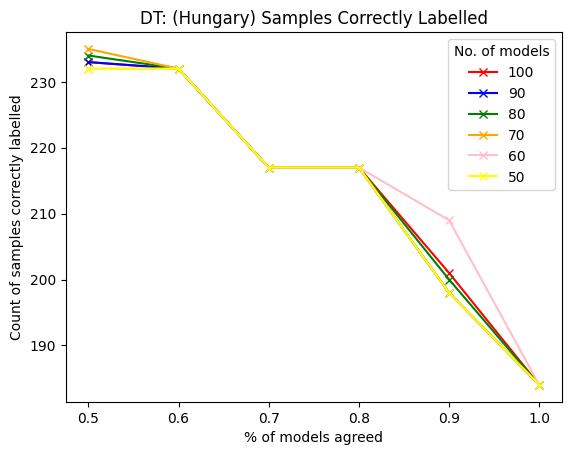

In [469]:
# count_correctly_labelled


fig = plt.figure()
# x = 
plt.plot(count_correctly_labelled[100].keys(), count_correctly_labelled[100].values(), marker='x', color='red', label='100')
# plt.scatter(bkd_exp_results[100].keys(), derived_label_match_results[100].values(), s=list(bkd_exp_results[100].values()), color='red', alpha=0.6)

plt.plot(count_correctly_labelled[90].keys(), count_correctly_labelled[90].values(), marker='x', color='blue', label='90')
# plt.scatter(bkd_exp_results[90].keys(), derived_label_match_results[90].values(), s=list(bkd_exp_results[90].values()), color='blue', alpha=0.6)

plt.plot(count_correctly_labelled[80].keys(), count_correctly_labelled[80].values(), marker='x', color='green', label='80')
# plt.scatter(bkd_exp_results[80].keys(), derived_label_match_results[80].values(), s=list(bkd_exp_results[80].values()), color='green', alpha=0.6)

plt.plot(count_correctly_labelled[70].keys(), count_correctly_labelled[70].values(), marker='x', color='orange', label='70')
# plt.scatter(bkd_exp_results[70].keys(), derived_label_match_results[70].values(), s=list(bkd_exp_results[70].values()), color='orange', alpha=0.6)

plt.plot(count_correctly_labelled[60].keys(), count_correctly_labelled[60].values(), marker='x', color='pink', label='60')
# plt.scatter(bkd_exp_results[60].keys(), derived_label_match_results[60].values(), s=list(bkd_exp_results[60].values()), color='pink', alpha=0.6)

plt.plot(count_correctly_labelled[50].keys(), count_correctly_labelled[50].values(), marker='x', color='yellow', label='50')
# plt.scatter(bkd_exp_results[50].keys(), derived_label_match_results[50].values(), s=list(bkd_exp_results[50].values()), color='yellow', alpha=0.6)

plt.xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.xlabel("% of models agreed")
plt.ylabel("Count of samples correctly labelled")
plt.legend(title='No. of models')
plt.title("{}".format(model_name+": ("+derived_dataset+') Samples Correctly Labelled'))

plt.savefig(model_name+"_"+derived_dataset+'_Forward_Expr_Samples_Correctly_Labelled.png', dpi=600)

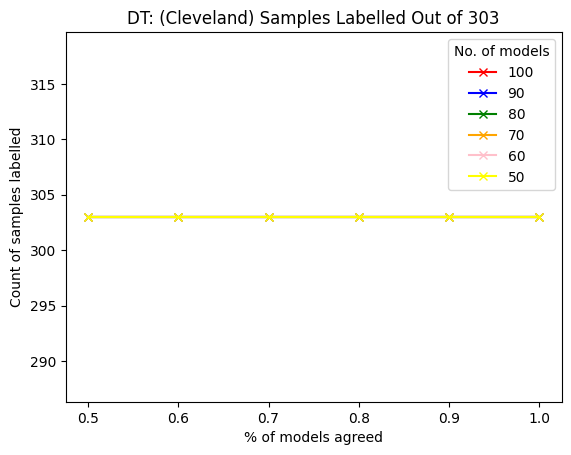

In [470]:
fig = plt.figure()
# x = 
plt.plot(bkd_exp_results[100].keys(), bkd_exp_results[100].values(), marker='x', color='red', label='100')
# plt.scatter(bkd_exp_results[100].keys(), derived_label_match_results[100].values(), s=list(bkd_exp_results[100].values()), color='red', alpha=0.6)

plt.plot(bkd_exp_results[90].keys(), bkd_exp_results[90].values(), marker='x', color='blue', label='90')
# plt.scatter(bkd_exp_results[90].keys(), derived_label_match_results[90].values(), s=list(bkd_exp_results[90].values()), color='blue', alpha=0.6)

plt.plot(bkd_exp_results[80].keys(), bkd_exp_results[80].values(), marker='x', color='green', label='80')
# plt.scatter(bkd_exp_results[80].keys(), derived_label_match_results[80].values(), s=list(bkd_exp_results[80].values()), color='green', alpha=0.6)

plt.plot(bkd_exp_results[70].keys(), bkd_exp_results[70].values(), marker='x', color='orange', label='70')
# plt.scatter(bkd_exp_results[70].keys(), derived_label_match_results[70].values(), s=list(bkd_exp_results[70].values()), color='orange', alpha=0.6)

plt.plot(bkd_exp_results[60].keys(), bkd_exp_results[60].values(), marker='x', color='pink', label='60')
# plt.scatter(bkd_exp_results[60].keys(), derived_label_match_results[60].values(), s=list(bkd_exp_results[60].values()), color='pink', alpha=0.6)

plt.plot(bkd_exp_results[50].keys(), bkd_exp_results[50].values(), marker='x', color='yellow', label='50')
# plt.scatter(bkd_exp_results[50].keys(), derived_label_match_results[50].values(), s=list(bkd_exp_results[50].values()), color='yellow', alpha=0.6)

plt.xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.xlabel("% of models agreed")
plt.ylabel("Count of samples labelled")
plt.legend(title='No. of models')
plt.title("{}".format(model_name+": ("+base_dataset+') Samples Labelled Out of '+str(base_dataset_count)))

plt.savefig(model_name+"_"+base_dataset+'_Reverse_Expr_Samples_Labelled.png', dpi=600)